In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# Suppress warnings
warnings.filterwarnings('ignore')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Large_Customer_Churn_Dataset.csv')

df.head()

,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn
0,1000001,Male,34,France,14,Two-year,21.58,7933.34,Bank transfer,1,No
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,Yes
2,1000003,Male,50,Germany,57,Two-year,111.12,6321.20,Bank transfer,1,No
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,Yes
4,1000005,Male,30,Spain,53,Two-year,62.48,4922.75,Direct debit,1,No


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

In [4]:
print(df['Tenure'].max())

59


In [5]:
print(df['Age'].max())

69


In [6]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 9) for i in range(1, 59, 10)]

df['tenure_group'] = pd.cut(df.Tenure, range(1, 70, 10), right=False, labels=labels)

In [7]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 9) for i in range(1, 69, 10)]

df['age_group'] = pd.cut(df.Age, range(1, 80, 10), right=False, labels=labels)

In [8]:
df['age_group'].value_counts()

,count
age_group,
41 - 50,195
51 - 60,192
21 - 30,188
61 - 70,185
31 - 40,182
11 - 20,58
1 - 10,0


In [9]:
df['tenure_group'].value_counts()

,count
tenure_group,
41 - 50,181
21 - 30,180
31 - 40,161
11 - 20,160
51 - 60,160
1 - 10,158


In [10]:
df.head()

,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
0,1000001,Male,34,France,14,Two-year,21.58,7933.34,Bank transfer,1,No,11 - 20,31 - 40
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,Yes,11 - 20,21 - 30
2,1000003,Male,50,Germany,57,Two-year,111.12,6321.20,Bank transfer,1,No,51 - 60,41 - 50
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,Yes,31 - 40,31 - 40
4,1000005,Male,30,Spain,53,Two-year,62.48,4922.75,Direct debit,1,No,51 - 60,21 - 30


# **UNIPLOT**

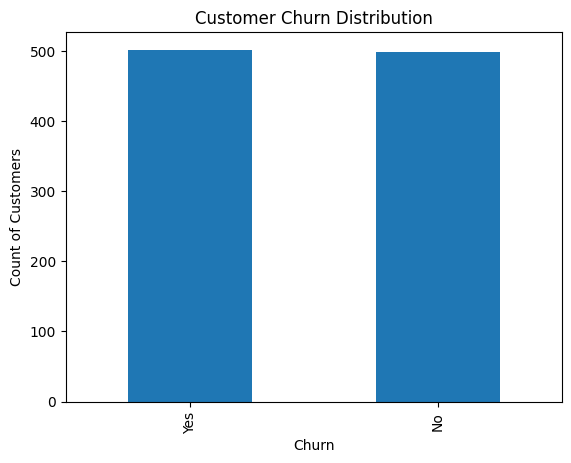

In [11]:
import matplotlib.pyplot as plt



df['Churn'].value_counts().plot(kind='bar')

plt.xlabel('Churn')
plt.ylabel('Count of Customers')
plt.title('Customer Churn Distribution')

plt.show()

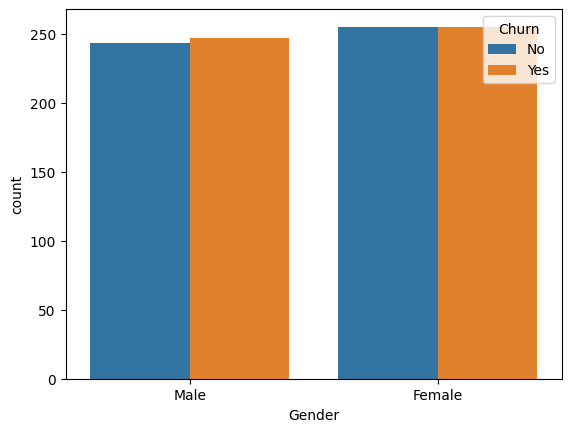

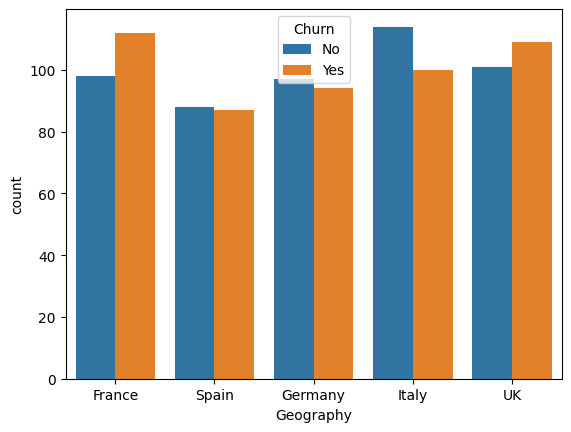

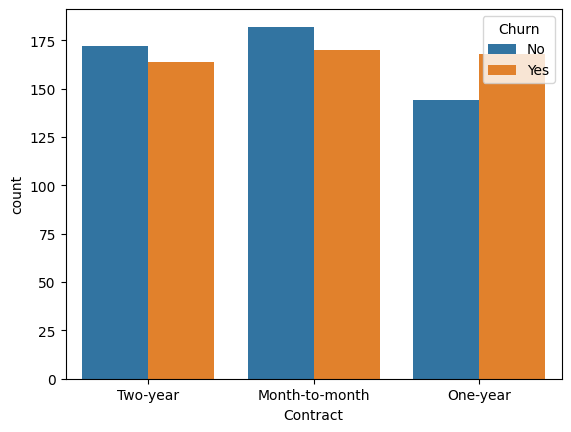

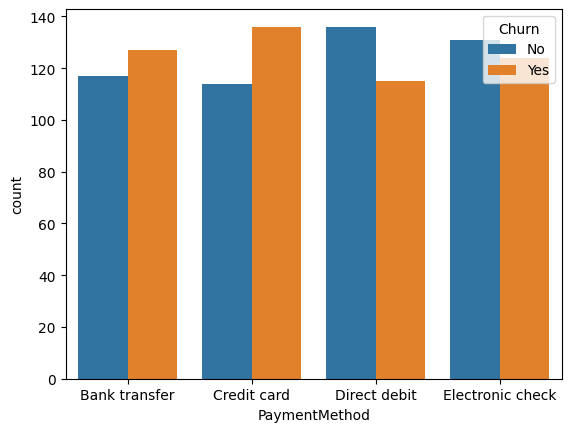

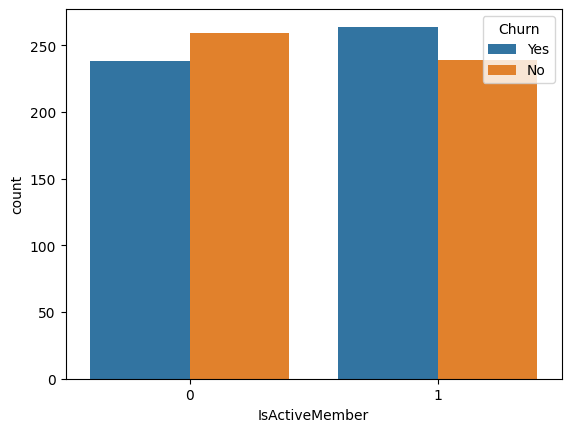

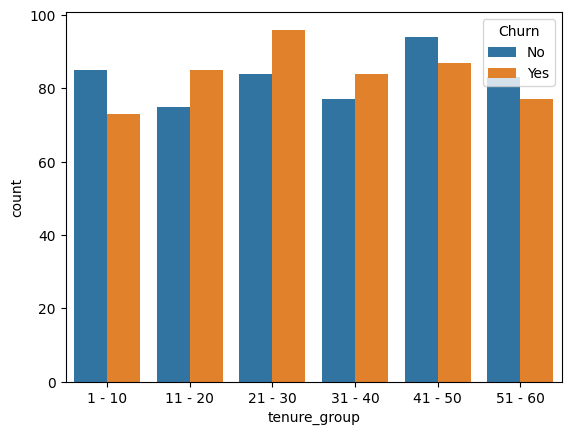

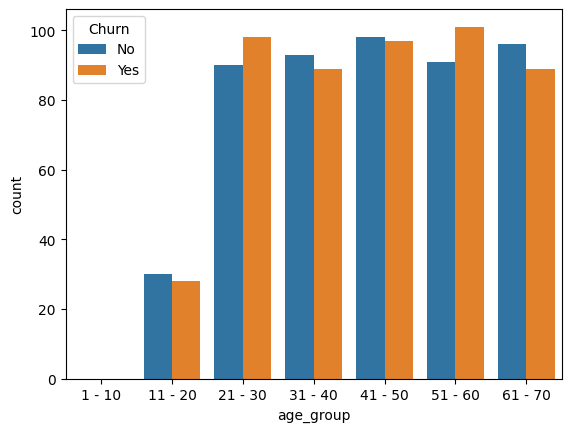

In [12]:
for i, predictor in enumerate(df.drop(columns=['Churn', 'CustomerID','Age','Tenure','TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Churn')

In [13]:
#drop column customerID and tenure
df.drop(columns= ['CustomerID','Tenure'], inplace=True)
df.head()

,Gender,Age,Geography,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
0,Male,34,France,Two-year,21.58,7933.34,Bank transfer,1,No,11 - 20,31 - 40
1,Female,26,Spain,Month-to-month,27.71,5869.34,Credit card,0,Yes,11 - 20,21 - 30
2,Male,50,Germany,Two-year,111.12,6321.20,Bank transfer,1,No,51 - 60,41 - 50
3,Male,37,Spain,Month-to-month,55.49,7956.44,Bank transfer,0,Yes,31 - 40,31 - 40
4,Male,30,Spain,Two-year,62.48,4922.75,Direct debit,1,No,51 - 60,21 - 30


In [14]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,False,True,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,26,27.71,5869.34,0,True,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,50,111.12,6321.20,1,False,True,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
3,37,55.49,7956.44,0,False,True,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,30,62.48,4922.75,1,False,True,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False


In [15]:
df.isnull().sum()

,0
Gender,0
Age,0
Geography,0
Contract,0
MonthlyCharges,0
TotalCharges,0
PaymentMethod,0
IsActiveMember,0
Churn,0
tenure_group,0


In [16]:
df.describe()

,Age,MonthlyCharges,TotalCharges,IsActiveMember
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.799000,70.124000,4066.221960,0.503000
std,15.133857,28.476322,2233.265597,0.500241
min,18.000000,20.130000,201.450000,0.000000
25%,31.000000,45.737500,2190.175000,0.000000
50%,44.000000,70.670000,4039.230000,1.000000
75%,57.000000,95.192500,5993.272500,1.000000
max,69.000000,119.760000,7973.210000,1.000000


In [17]:
df.dtypes

,0
Gender,object
Age,int64
Geography,object
Contract,object
MonthlyCharges,float64
TotalCharges,float64
PaymentMethod,object
IsActiveMember,int64
Churn,object
tenure_group,category


In [18]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing 'TotalCharges' with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [19]:
churn_counts = df['Churn'].value_counts()
display(churn_counts)

,count
Churn,
Yes,502
No,498


In [20]:
df['Churn'] = np.where(df.Churn == 'Yes',1,0)

In [21]:
churn_counts = df['Churn'].value_counts()
display(churn_counts)

,count
Churn,
1,502
0,498



Numeric correlation matrix:


,Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn
Age,1.000000,-0.030638,-0.003164,0.039813,-0.014557
MonthlyCharges,-0.030638,1.000000,-0.011850,-0.009037,-0.011805
TotalCharges,-0.003164,-0.011850,1.000000,0.009972,0.060062
IsActiveMember,0.039813,-0.009037,0.009972,1.000000,0.045977
Churn,-0.014557,-0.011805,0.060062,0.045977,1.000000


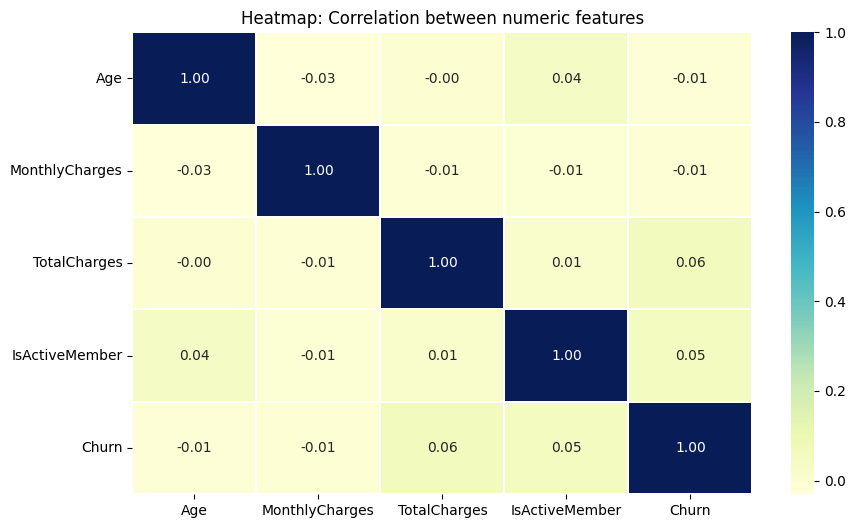

In [22]:
# Heatmap - correlation of numeric features
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    print("\nNumeric correlation matrix:")
    display(corr)
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.3)
    plt.title("Heatmap: Correlation between numeric features")
    plt.show()
else:
    print("\nNo numeric columns (or too few) for correlation heatmap.")

In [ ]:
import seaborn as sns

In [ ]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,0,False,True,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,26,27.71,5869.34,0,1,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,50,111.12,6321.20,1,0,False,True,False,True,False,...,False,False,True,False,False,False,False,True,False,False
3,37,55.49,7956.44,0,1,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
4,30,62.48,4922.75,1,0,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False


Text(0.5, 1.0, 'Monthly charges by churn')

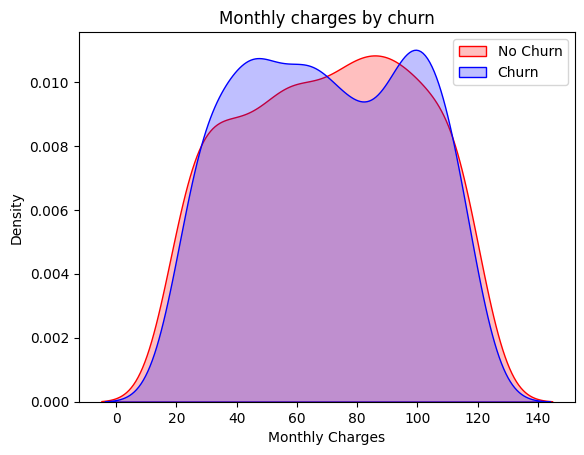

In [ ]:
Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

Text(0.5, 1.0, 'Total charges by churn')

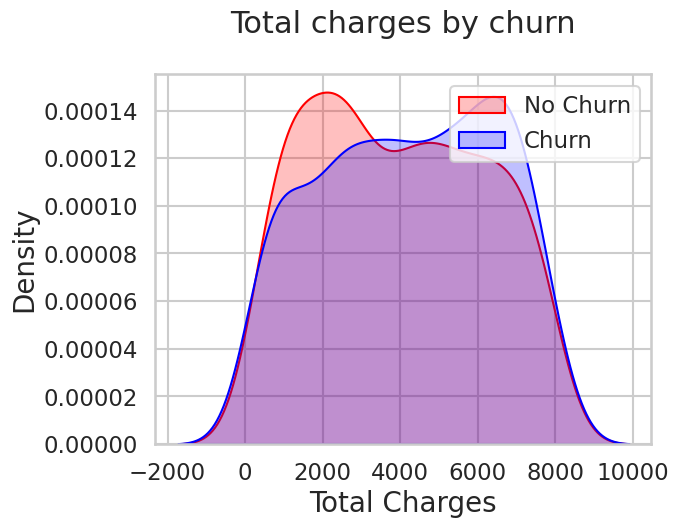

In [ ]:
Mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Total Charges')
Mth.set_title('Total charges by churn')

<Axes: >

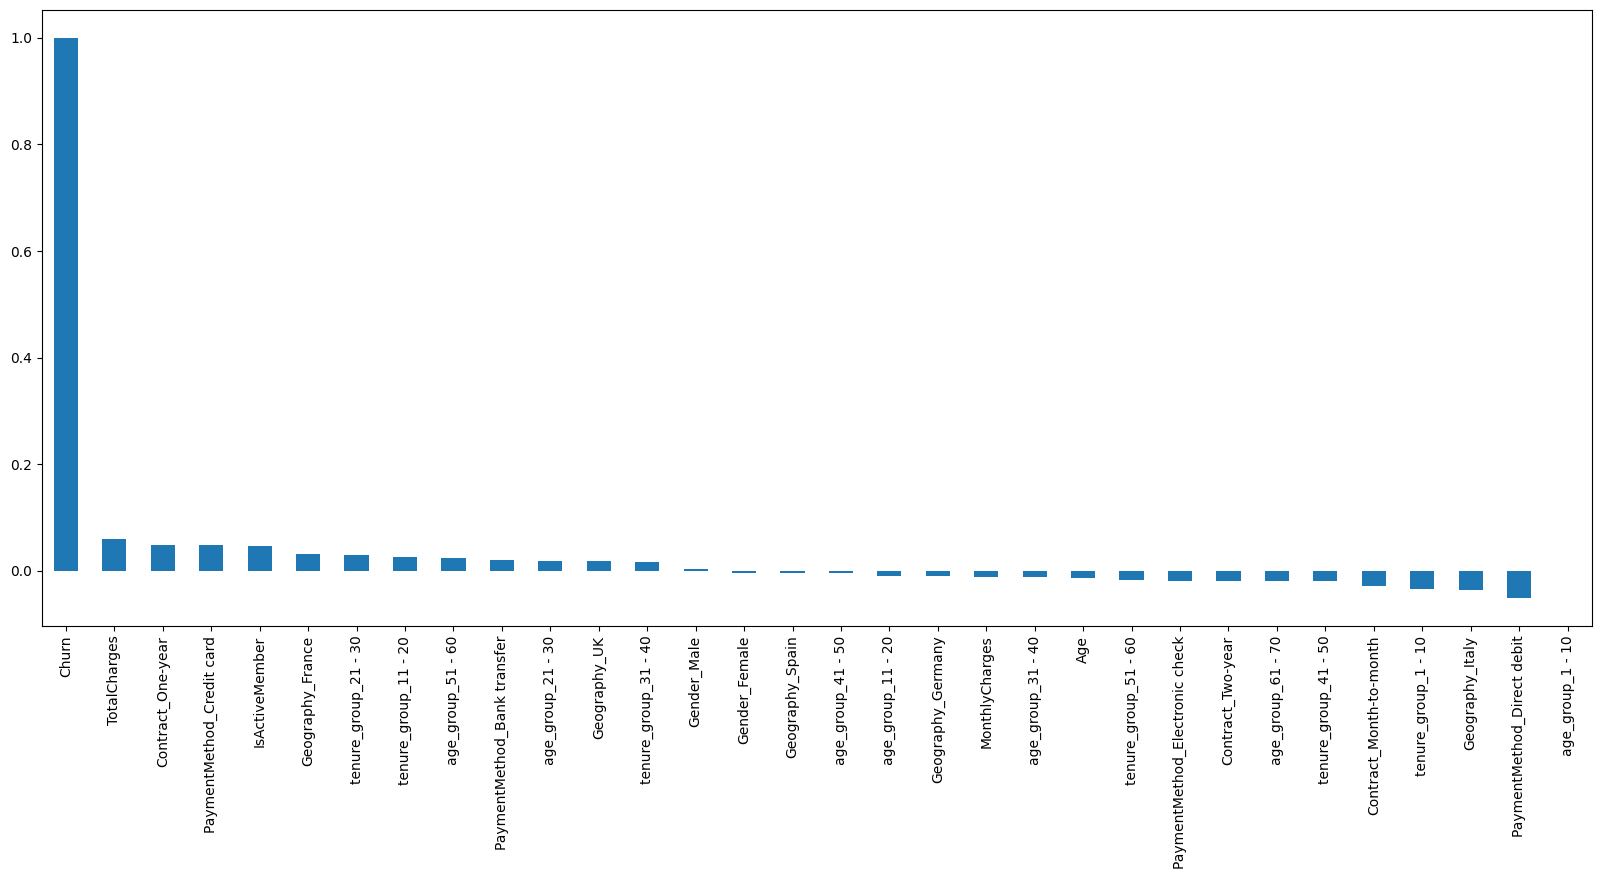

In [ ]:
plt.figure(figsize=(20,8))
df_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

<Axes: >

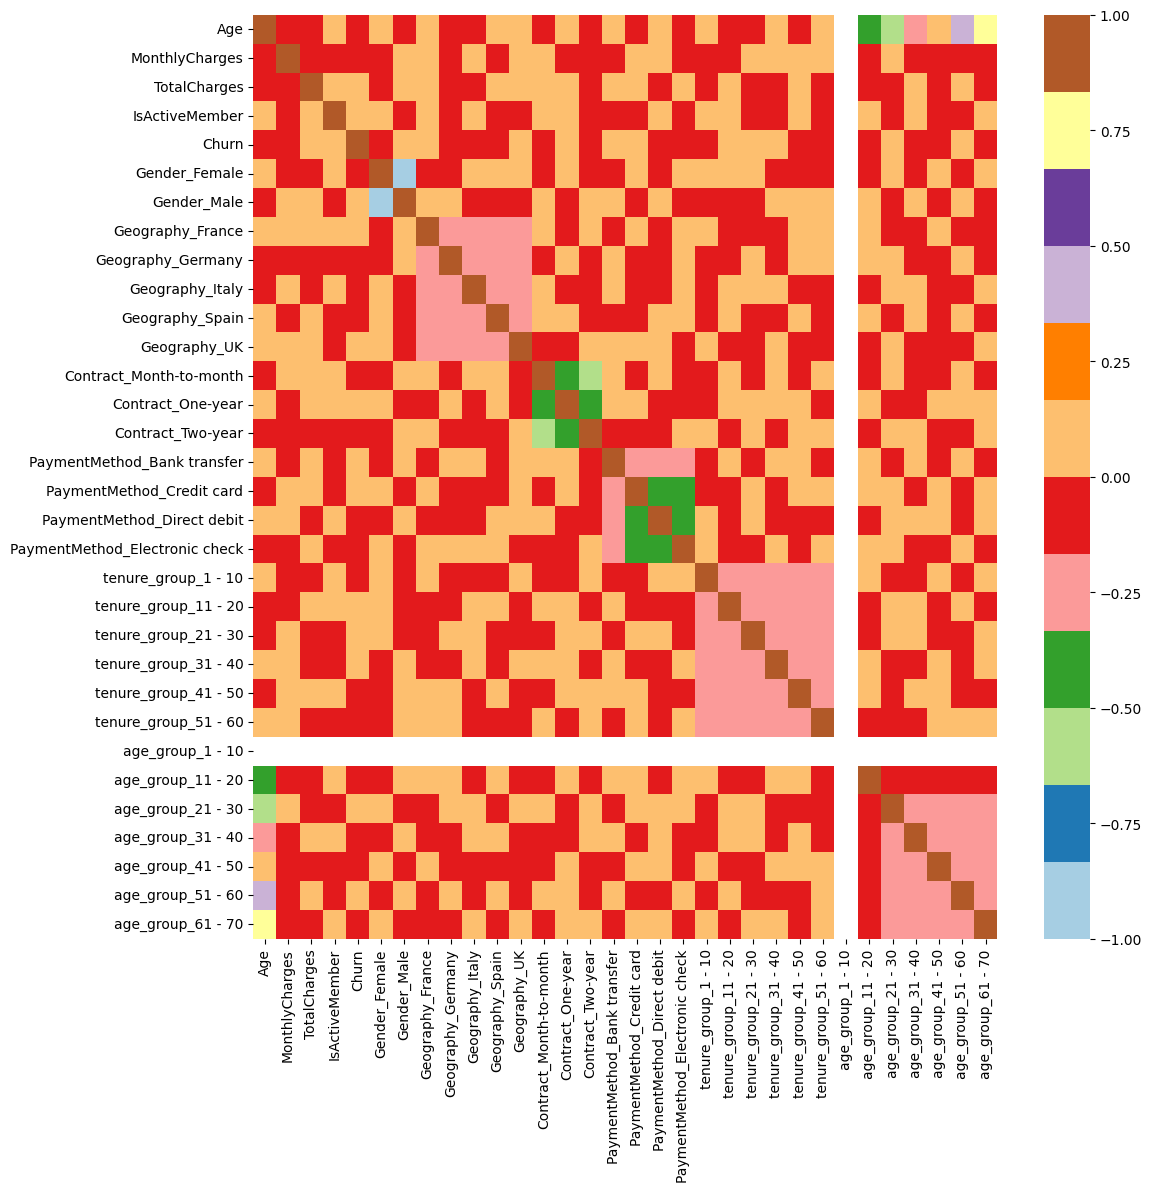

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df_dummies.corr(), cmap="Paired")

In [ ]:
from sklearn.metrics import accuracy_score
new_df1=df.loc[df["Churn"]==0]
new_df0=df.loc[df["Churn"]==1]

In [ ]:
def uniplot(df, col, title, hue=None):
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    n_categories = len(df[col].unique())
    n_hue_groups = len(df[hue].unique()) if hue else 1
    width = n_categories + 7 + 4 * n_hue_groups

    fig, ax = plt.subplots()
    fig.set_size_inches(width, 8)
    plt.xticks(rotation=45)
    plt.yscale('linear')
    plt.title(title)
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, hue=hue, palette='bright')
    plt.tight_layout()
    plt.show()

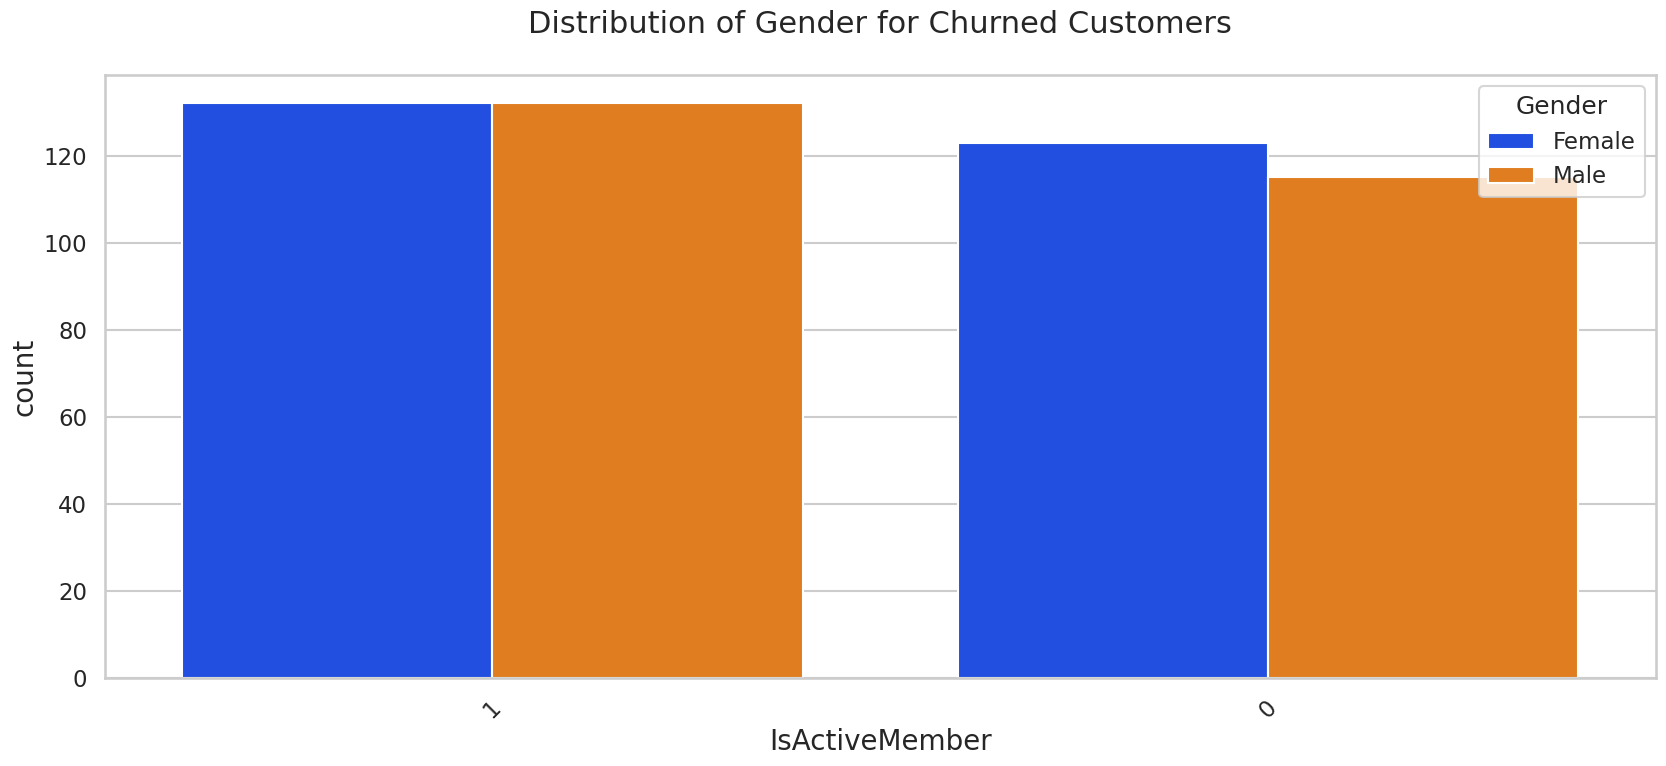

In [ ]:
uniplot(new_df0, col='IsActiveMember', title='Distribution of Gender for Churned Customers', hue='Gender')

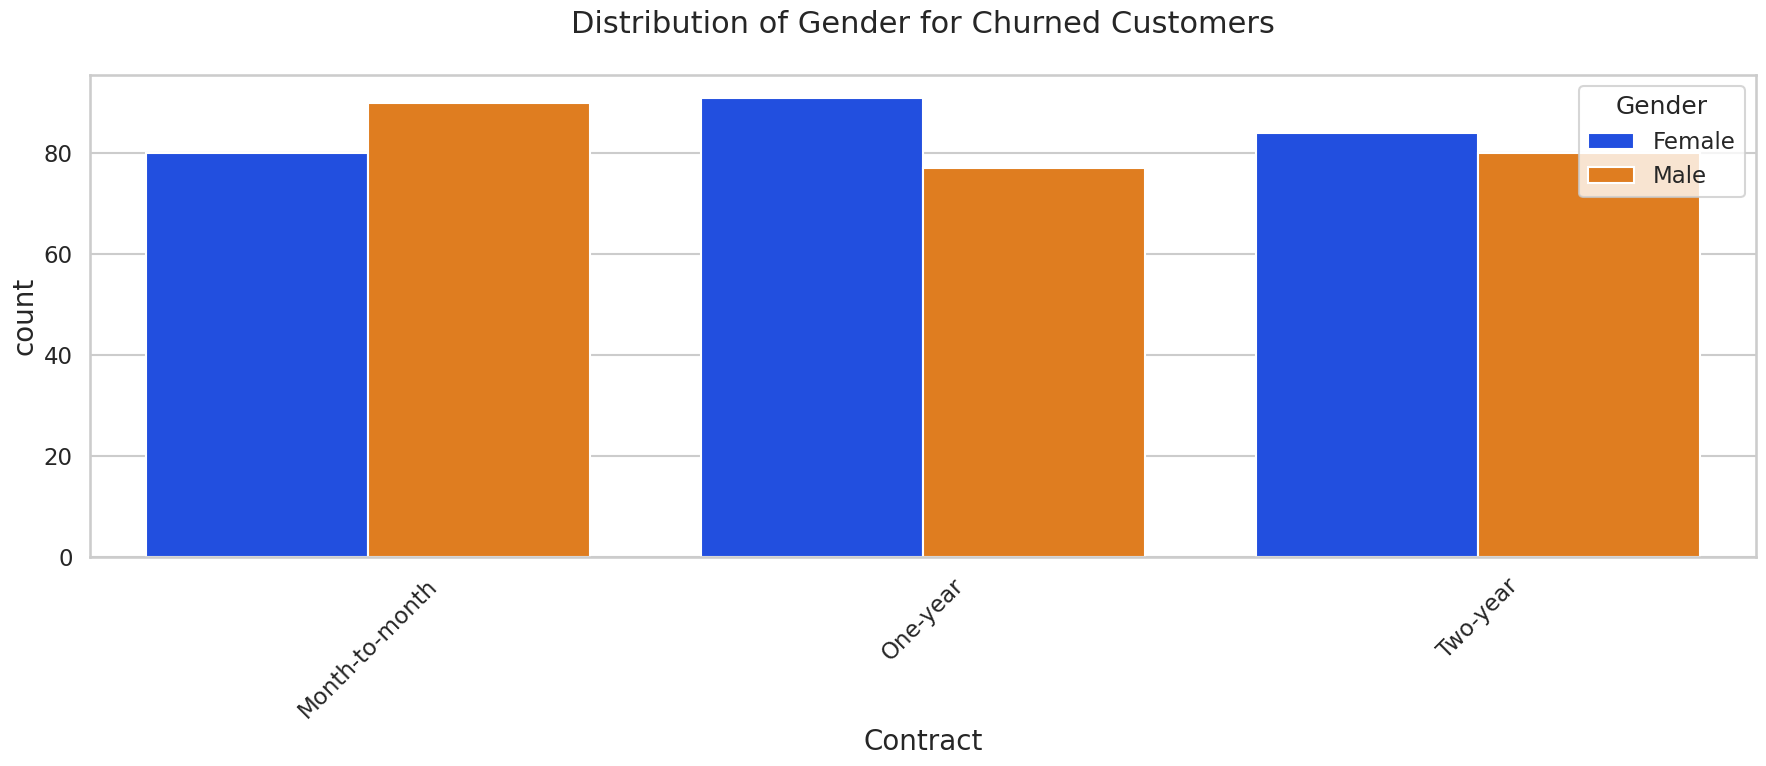

In [ ]:
uniplot(new_df0, col='Contract', title='Distribution of Gender for Churned Customers', hue='Gender')

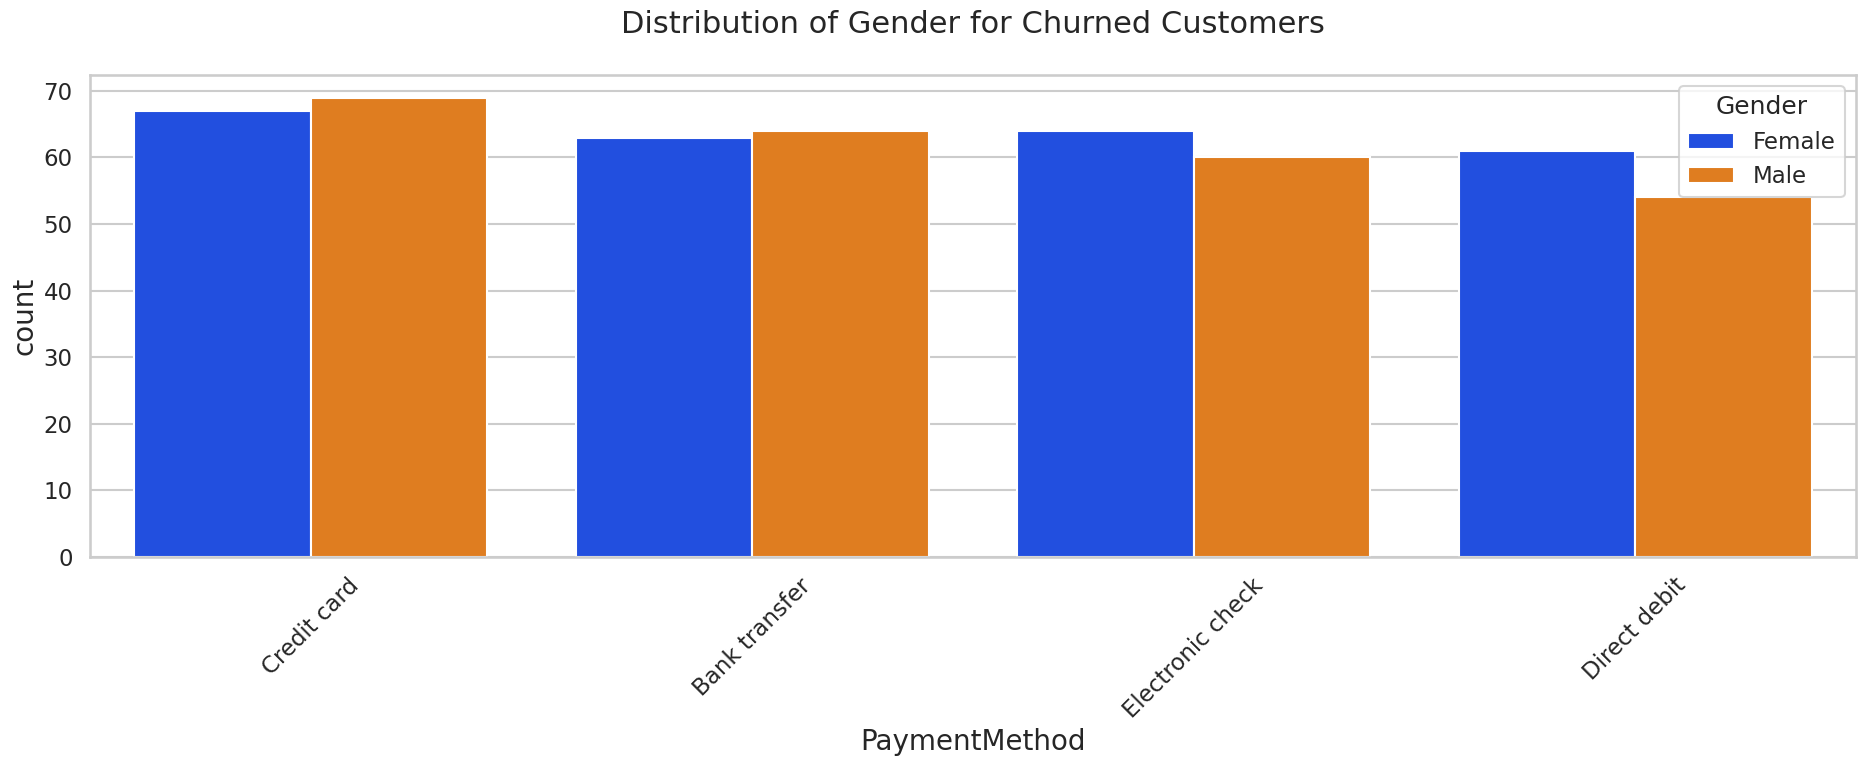

In [ ]:
uniplot(new_df0, col='PaymentMethod', title='Distribution of Gender for Churned Customers', hue='Gender')

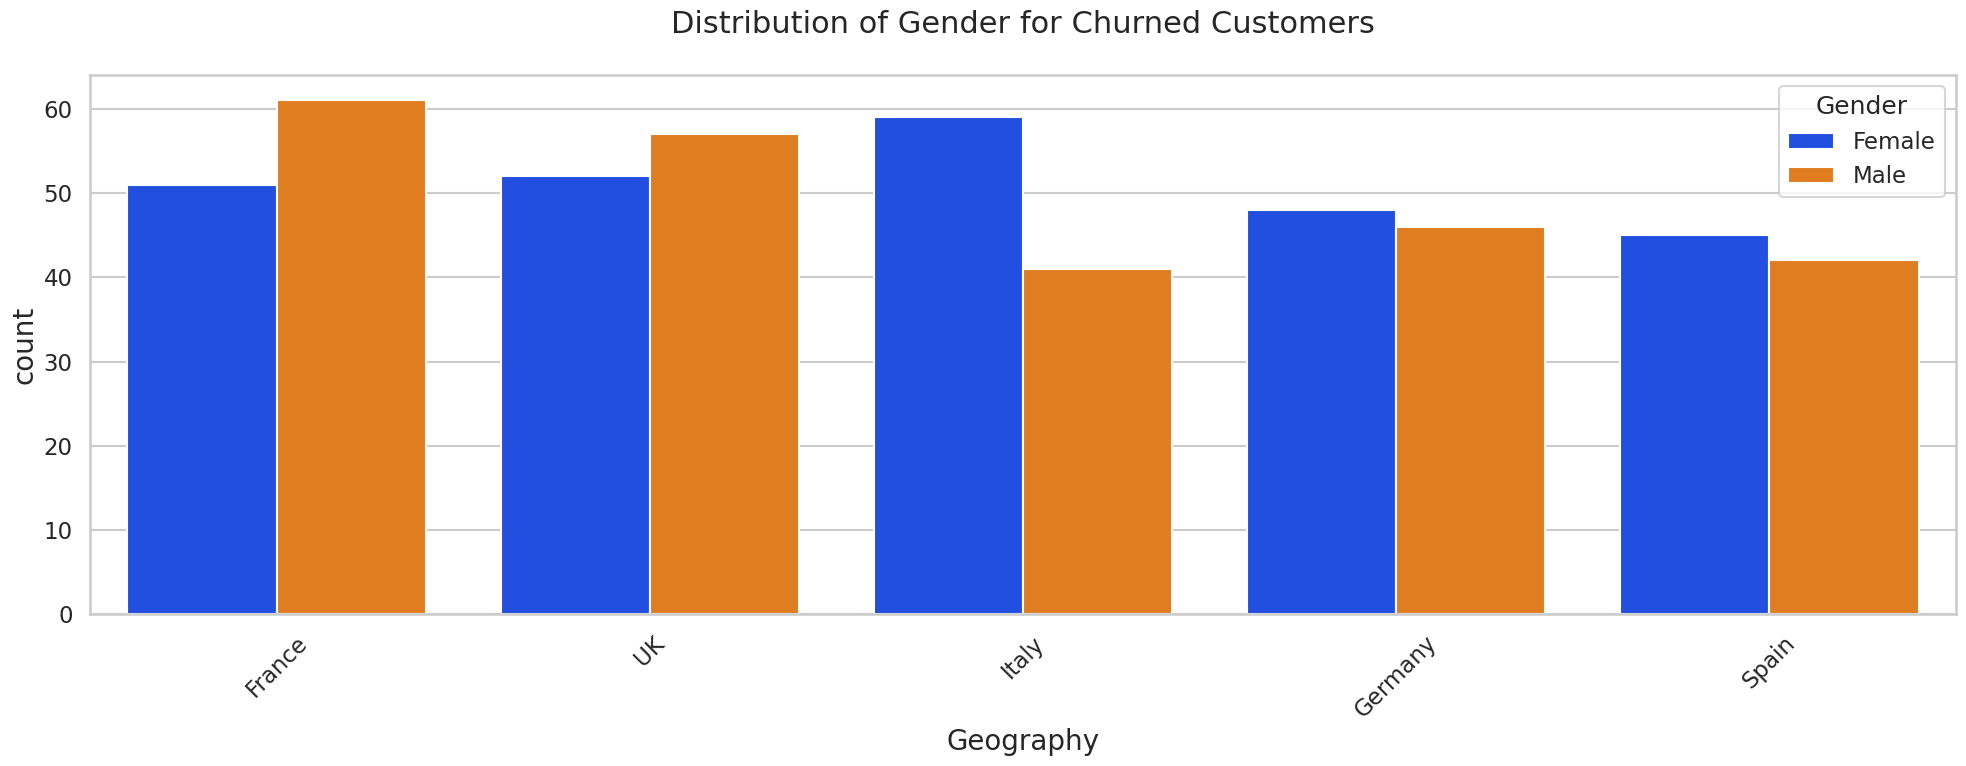

In [ ]:
uniplot(new_df0, col='Geography', title='Distribution of Gender for Churned Customers', hue='Gender')

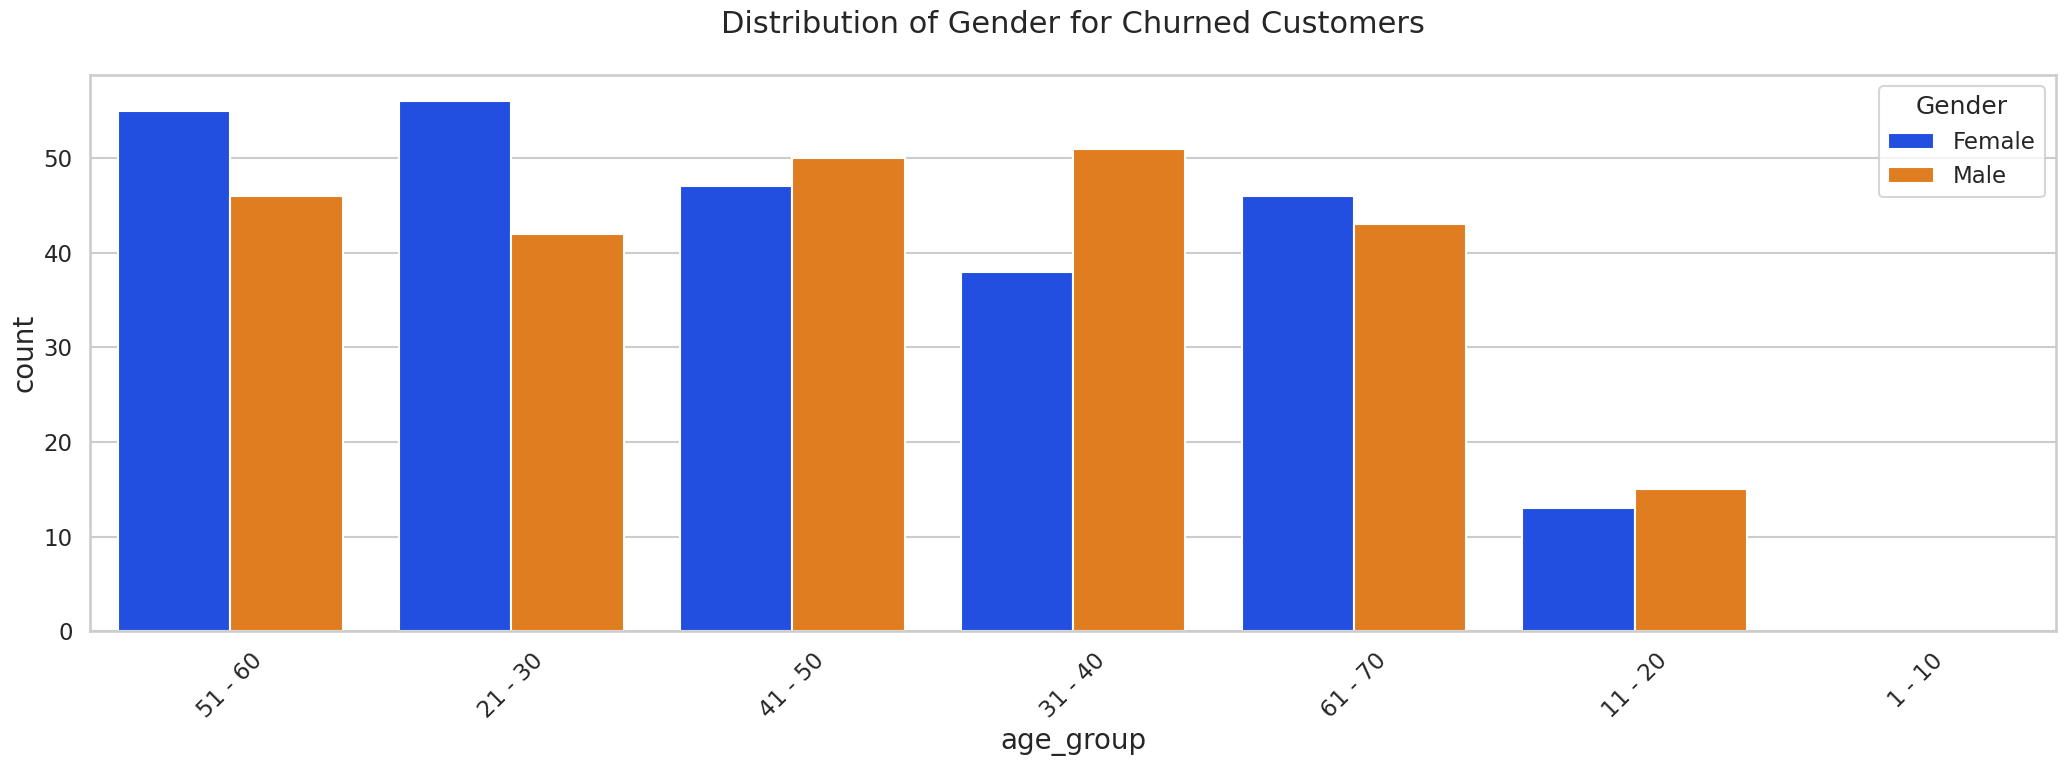

In [ ]:
uniplot(new_df0, col='age_group', title='Distribution of Gender for Churned Customers', hue='Gender')

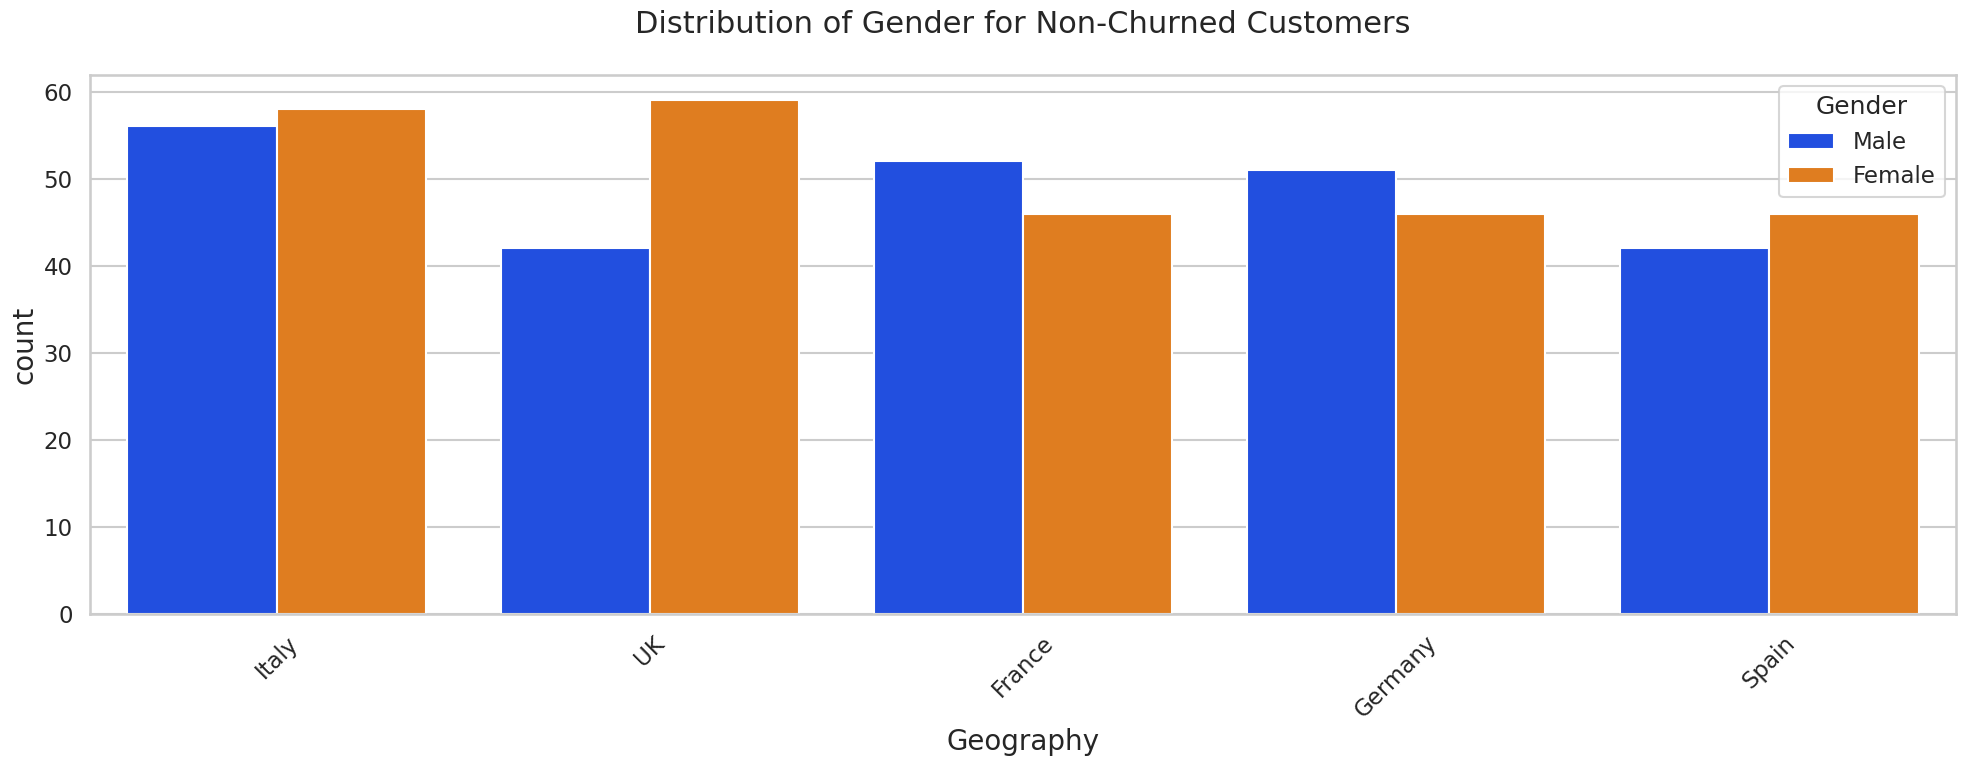

In [ ]:
uniplot(new_df1, col='Geography', title='Distribution of Gender for Non-Churned Customers', hue='Gender')

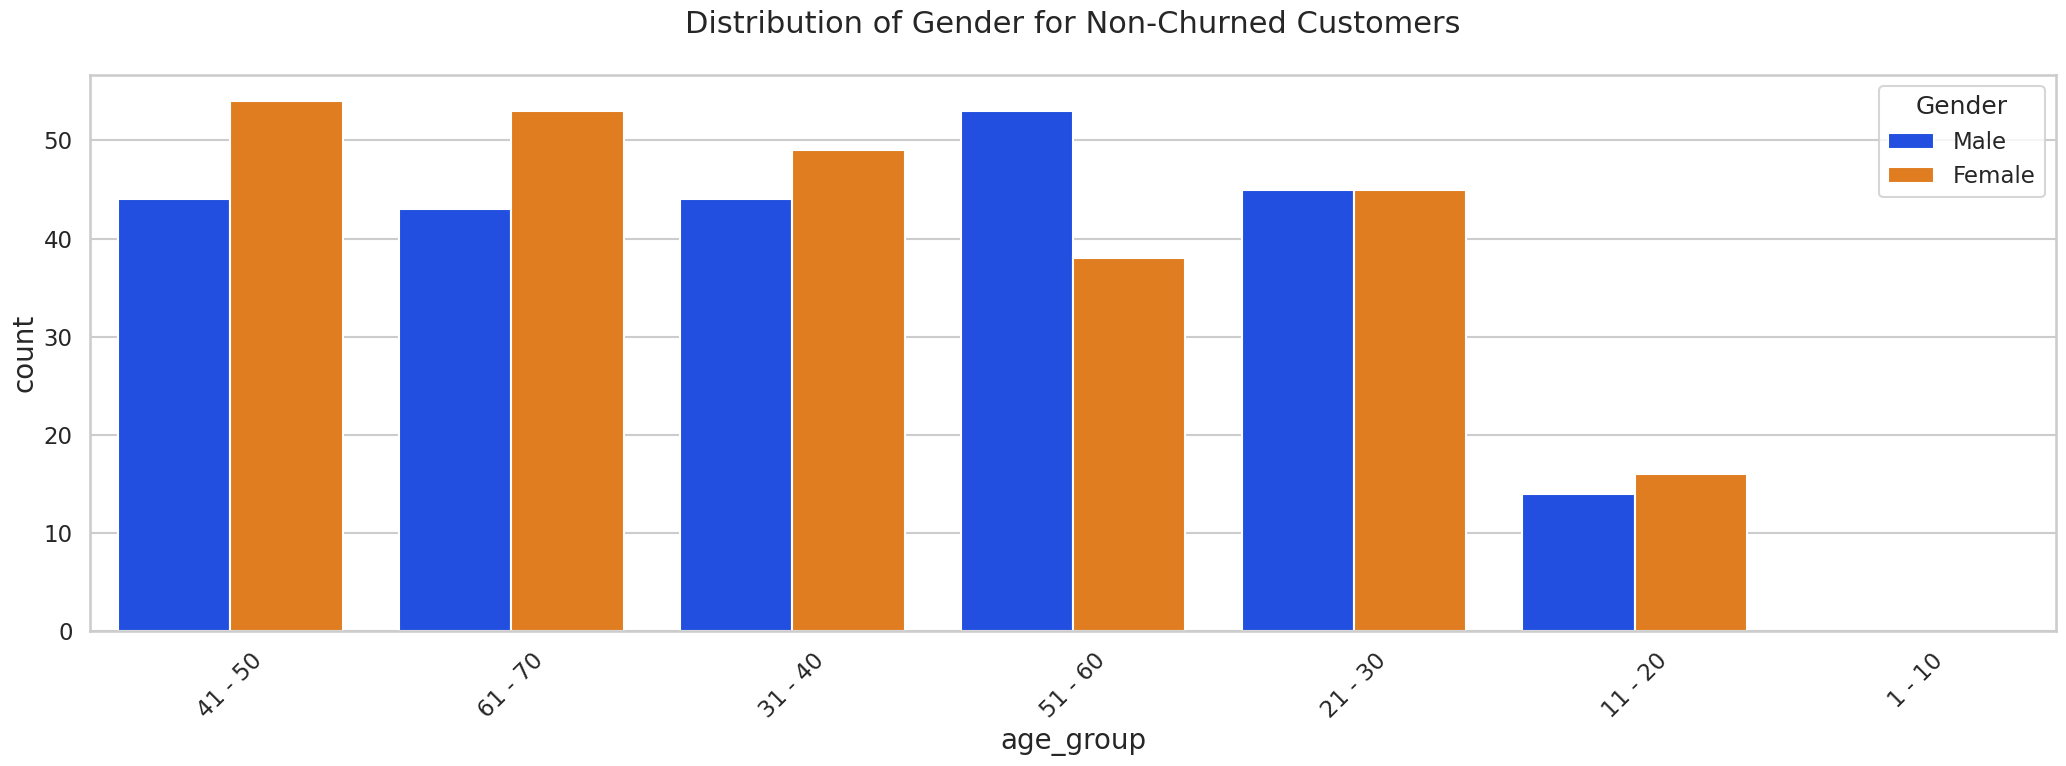

In [ ]:
uniplot(new_df1, col='age_group', title='Distribution of Gender for Non-Churned Customers', hue='Gender')

In [ ]:
df_dummies.to_csv('df_churn.csv')

**Model Building and Testing**

In [ ]:
%pip install imbalanced-learn

In [ ]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN

In [ ]:
df=pd.read_csv("df_churn.csv")
df.head()

,Unnamed: 0,Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn,Gender_Female,Gender_Male,Geography_France,Geography_Germany,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,0,34,21.58,7933.34,1,0,False,True,True,False,...,False,False,False,False,False,False,True,False,False,False
1,1,26,27.71,5869.34,0,1,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,2,50,111.12,6321.20,1,0,False,True,False,True,...,False,False,True,False,False,False,False,True,False,False
3,3,37,55.49,7956.44,0,1,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4,4,30,62.48,4922.75,1,0,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
df=df.drop('Unnamed: 0',axis=1)

In [ ]:
x=df.drop('Churn',axis=1)
x

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,False,True,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,26,27.71,5869.34,0,True,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,50,111.12,6321.20,1,False,True,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
3,37,55.49,7956.44,0,False,True,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,30,62.48,4922.75,1,False,True,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,42,32.75,6815.82,1,False,True,True,False,False,False,...,False,True,False,False,False,False,False,True,False,False
996,26,100.02,5544.36,1,False,True,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
997,21,106.30,2462.34,1,True,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False
998,31,35.07,1771.42,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
x = x.replace({False: 0, True: 1})
x

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,26,27.71,5869.34,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,50,111.12,6321.20,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
3,37,55.49,7956.44,0,0,1,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
4,30,62.48,4922.75,1,0,1,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,42,32.75,6815.82,1,0,1,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
996,26,100.02,5544.36,1,0,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
997,21,106.30,2462.34,1,1,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
998,31,35.07,1771.42,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
x.head()

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,...,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,26,27.71,5869.34,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,50,111.12,6321.20,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
3,37,55.49,7956.44,0,0,1,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
4,30,62.48,4922.75,1,0,1,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
y=df['Churn']
y

,Churn
0,0
1,1
2,0
3,1
4,0
...,...
995,1
996,1
997,0
998,0


In [ ]:
from sklearn.preprocessing import StandardScaler



x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

scaler = StandardScaler()
scaler.fit(x_train)

X_train_scaled = scaler.transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
pd.merge(pd.DataFrame(X_train_scaled), pd.DataFrame(X_test_scaled), how='inner')

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

RandomForestClassifier(
    random_state=42
)

RandomForestClassifier(random_state=42)

In [ ]:
model_rf=RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)

In [ ]:
model_rf.fit(X_train_scaled,y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [ ]:
y_pred_rf=model_rf.predict(X_test_scaled)

In [ ]:
rf_cm=confusion_matrix(y_test, y_pred_rf)
rf_cm

array([[42, 58],
       [40, 60]])

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.51
Precision: 0.5084745762711864
Recall   : 0.6
F1 Score : 0.5504587155963303


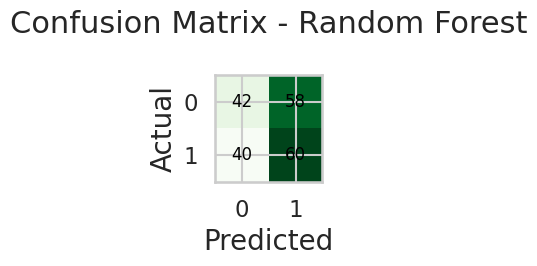

In [ ]:
plt.figure(figsize=(4,3))
plt.imshow(rf_cm, cmap='Greens', interpolation='nearest')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for (i, j), v in np.ndenumerate(rf_cm):
    plt.text(j, i, str(v), ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
rf_prob = model_rf.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, rf_prob)
print(f"\nRandom Forest AUC Score: {auc_score:.4f}")


Random Forest AUC Score: 0.4941


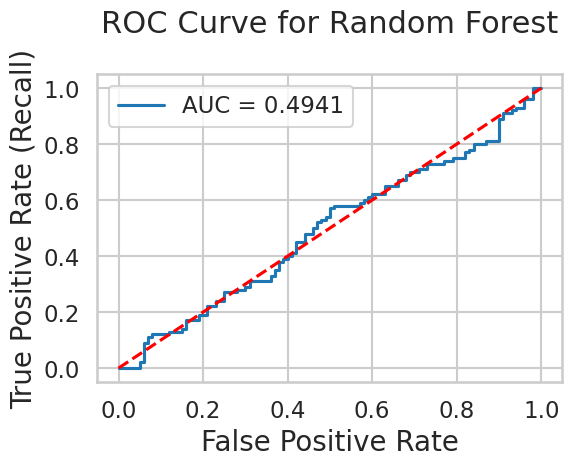

In [ ]:
# 4. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
model_rf.score(X_test_scaled,y_test)

0.51

In [ ]:
print(classification_report(y_test, y_pred_rf, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.51      0.42      0.46       100
           1       0.51      0.60      0.55       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.51      0.51      0.51       200



In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.51
Precision: 0.5084745762711864
Recall   : 0.6
F1 Score : 0.5504587155963303


In [ ]:
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_acc

0.51

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.47      0.45      0.46       100\n           1       0.47      0.49      0.48       100\n\n    accuracy                           0.47       200\n   macro avg       0.47      0.47      0.47       200\nweighted avg       0.47      0.47      0.47       200\n'

In [ ]:
log_reg_acc = accuracy_score(y_test, y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[45, 55],
       [51, 49]])

Accuracy,AUC,Precision and Recall for LR

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.47
Precision: 0.47115384615384615
Recall   : 0.49
F1 Score : 0.4803921568627451


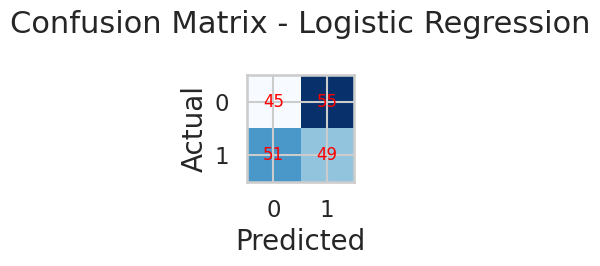

In [ ]:
plt.figure(figsize=(4,3))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center', color='red', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
coef = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

In [ ]:
coef.head(10)

,Feature,Coefficient
30,age_group_61 - 70,0.263183
29,age_group_51 - 60,0.209383
2,TotalCharges,0.146148
19,tenure_group_11 - 20,0.100536
3,IsActiveMember,0.080832
6,Geography_France,0.074879
14,PaymentMethod_Bank transfer,0.057640
12,Contract_One-year,0.054707
15,PaymentMethod_Credit card,0.043568
20,tenure_group_21 - 30,0.023932


In [ ]:
round(log_reg_acc, 4)
round(rf_acc, 4)

0.51

In [ ]:
from sklearn.model_selection import cross_val_score

scores_lr = cross_val_score(
    model, x, y,
    cv=5,
    scoring='roc_auc'
)

scores_rf = cross_val_score(
    model_rf, x, y,
    cv=5,
    scoring='roc_auc'
)

print(scores_lr.mean())
print(scores_rf.mean())

0.45723871587158715
0.481199501950195


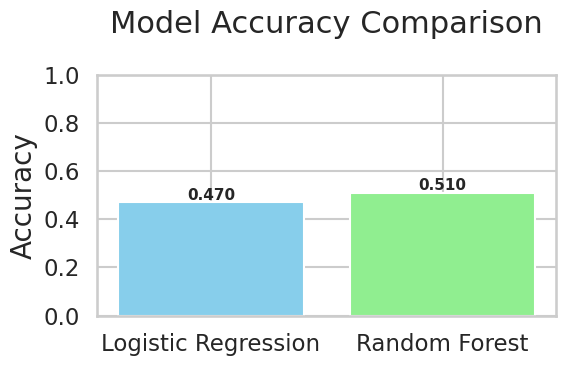

In [ ]:
accuracy = [log_reg_acc, rf_acc]
models = ['Logistic Regression', 'Random Forest']

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['skyblue', 'lightgreen'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

XGBoost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

Accuracy,AUC,Precision and Recall for XGBoost

In [ ]:
auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\nXG Boost AUC Score: {auc_score_xgb:.4f}")


XG Boost AUC Score: 0.5038


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.52
Precision: 0.5169491525423728
Recall   : 0.61
F1 Score : 0.5596330275229358


In [ ]:
rf_xgb = accuracy_score(y_test, y_pred_xgb)
rf_xgb

0.52

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[43 57]
 [39 61]]


In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
8               Geography_Italy    0.039227
19         tenure_group_11 - 20    0.039195
18          tenure_group_1 - 10    0.038869
15    PaymentMethod_Credit card    0.038757
14  PaymentMethod_Bank transfer    0.038676
22         tenure_group_41 - 50    0.037241
2                  TotalCharges    0.037166
1                MonthlyCharges    0.036242
6              Geography_France    0.036055
16   PaymentMethod_Direct debit    0.035105


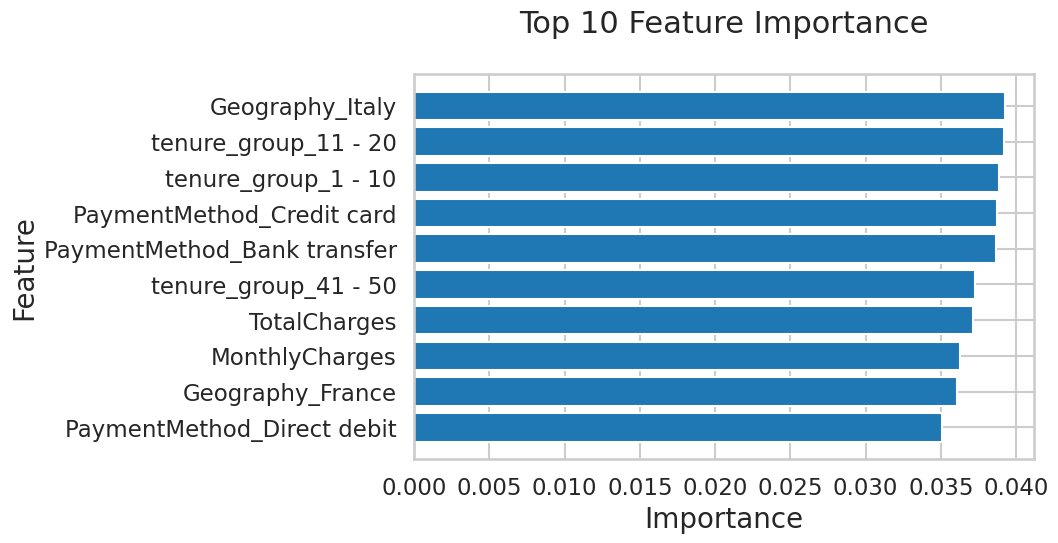

In [ ]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

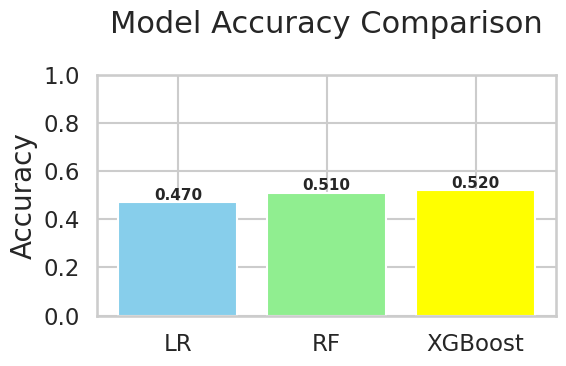

In [ ]:
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
accuracy = [log_reg_acc, rf_acc, rf_xgb]
models = ['LR', 'RF','XGBoost']

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['skyblue', 'lightgreen','yellow'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

RF vs XGBoost

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
rf_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("RF AUC scores:", rf_scores)
print("RF Mean AUC:", rf_scores.mean())
print("RF Std:", rf_scores.std())

RF AUC scores: [0.51135    0.44205    0.44665    0.49889989 0.51425143]
RF Mean AUC: 0.48264026302630264
RF Std: 0.031719894456473885


In [ ]:
xgb_scores = cross_val_score(
    xgb_model,
    x,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("XGBoost AUC scores:", xgb_scores)
print("XGBoost Mean AUC:", xgb_scores.mean())
print("XGBoost Std:", xgb_scores.std())

XGBoost AUC scores: [0.5305     0.4882     0.4608     0.50285029 0.49634963]
XGBoost Mean AUC: 0.49573998399839986
XGBoost Std: 0.022524833442110016


Interpretation:

*  Higher mean AUC → better model
*  Lower std → more stable model


Hence XGBoost is better than Random Forest

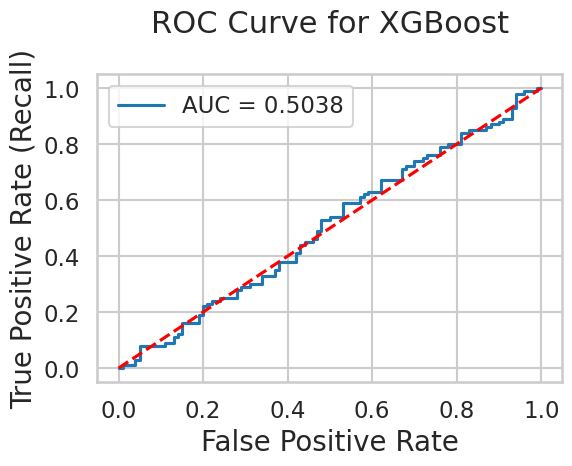

In [ ]:
# 4. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score_xgb:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve for XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()